In [7]:
from pathlib import Path
import json
from pycocotools.coco import COCO

# A) Paths 

DATA_ROOT = Path("../data/raw").resolve()
COCO_IMG_DIR = DATA_ROOT / "train2014"
COCOTEXT_JSON = DATA_ROOT / "cocotext.v2.json"

# Check 
print("Data root:", DATA_ROOT)
print("COCO images:", COCO_IMG_DIR)
print("COCO-Text:", COCOTEXT_JSON)


Data root: C:\dev\vision-ocr-accessibility-assistant\data\raw
COCO images: C:\dev\vision-ocr-accessibility-assistant\data\raw\train2014
COCO-Text: C:\dev\vision-ocr-accessibility-assistant\data\raw\cocotext.v2.json


In [8]:
with open(COCOTEXT_JSON, "r", encoding="utf-8") as f:
    cocotext = json.load(f)

def normalize_int_keys(d):
    out = {}
    for k, v in d.items():
        try:
            out[int(k)] = v
        except:
            out[k] = v
    return out

for key in ["imgs", "anns", "imgToAnns"]:
    if key in cocotext and isinstance(cocotext[key], dict):
        cocotext[key] = normalize_int_keys(cocotext[key])

imgToTextAnns = cocotext.get("imgToAnns", {})
textAnns = cocotext.get("anns", {})
textImgs = cocotext.get("imgs", {})

print(" Loaded COCO-Text")
print("Text images indexed:", len(imgToTextAnns))
print("Text annotations:", len(textAnns))

 Loaded COCO-Text
Text images indexed: 53686
Text annotations: 201126


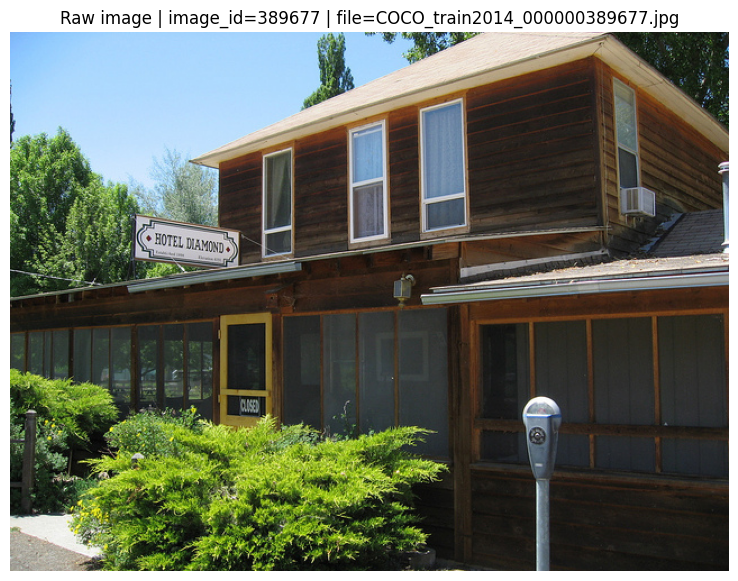

Selected image_id: 389677
File: COCO_train2014_000000389677.jpg
Image shape: (480, 640, 3)


In [ ]:
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

#  Pick an image WITH text + display it
# Why we do this:
# - Picking a random COCO image can give "no text" images.
# - imgToTextAnns already contains ONLY images that have at least 1 text annotation.
# So choosing from imgToTextAnns.keys() guarantees we will see text boxes later.

# 1) Pick a random image_id that has text
img_id = random.choice(list(imgToTextAnns.keys()))

# 2) Get image metadata (contains filename, width, height, etc.)
img_info = textImgs[img_id]
file_name = img_info["file_name"]  # e.g., "COCO_train2014_000000123456.jpg"

# 3) Build the full path to the actual image file
img_path = COCO_IMG_DIR / file_name

# 4) Safety check: confirm file exists
assert img_path.exists(), f"Image file not found: {img_path}"

# 5) Load the image pixels into memory
img = mpimg.imread(img_path)

# 6) Display the image (raw image)
plt.figure(figsize=(10, 7))
plt.imshow(img)
plt.axis("off")
plt.title(f"Raw image | image_id={img_id} | file={file_name}")
plt.show()

# Print a quick summary for debugging / logging
print("Selected image_id:", img_id)
print("File:", file_name)
print("Image shape:", img.shape)


In [10]:
# print("Annotations for image_id 432770:")
for ann in imgToTextAnns.get(432770, []):
    print(ann)
    

132461
132462
132463


In [11]:

# Print text in the image (from COCO-Text annotations)

# Goal:
# - For the image_id selected in Cell 3
# - Print the text strings annotated in COCO-Text
# - Include basic metadata (legibility)

# 1) Get all text annotation IDs for this image
ann_ids = imgToTextAnns[img_id]

print(f"Image ID: {img_id}")
print(f"Number of text annotations: {len(ann_ids)}\n")

# 2) Loop through annotations and print text
for i, ann_id in enumerate(ann_ids, start=1):
    ann = textAnns[ann_id]

    # Extract fields safely
    text = ann.get("utf8_string", "")
    legibility = ann.get("legibility", "unknown")

    # Some annotations may have empty or non-string text
    if not isinstance(text, str) or text.strip() == "":
        text = "[NO TRANSCRIPTION]"

    print(f"{i:02d}. [{legibility.upper()}] {text}")


Image ID: 389677
Number of text annotations: 5

01. [LEGIBLE] HOTEL
02. [LEGIBLE] DIAMOND
03. [ILLEGIBLE] [NO TRANSCRIPTION]
04. [ILLEGIBLE] [NO TRANSCRIPTION]
05. [ILLEGIBLE] [NO TRANSCRIPTION]


For image_id 432770, COCO-Text provides three text annotations, of which only one is labeled as legible (‘Electro’), illustrating the presence of both readable and unreadable text regions in natural scenes